# Relatório final — Ouvidoria Inteligente

Este notebook gera o **`RELATORIO.pdf`** (até 5 páginas) pedido na seção 6 do desafio. O relatório sintetiza as decisões, as dificuldades e os aprendizados das 4 entregas.

Os números do relatório não foram copiados à mão: cada seção abaixo os recalcula com o mesmo módulo (`ouvidoria.py`) e os mesmos dados (`manifestacoes.json`, `duplicatas_reais.json`) das entregas. No fim, o texto é montado em `RELATORIO.md` e convertido em PDF com `relatorio_pdf.py` (fpdf2).

In [1]:
import re
from datetime import datetime, timezone
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pypdf import PdfReader
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.manifold import TSNE
from sklearn.metrics import adjusted_rand_score
from sklearn.metrics.pairwise import cosine_similarity

from ouvidoria import (
    MODELO_PADRAO,
    MODELOS,
    STOPWORDS_PT,
    avaliar_deteccao,
    carregar_duplicatas_reais,
    carregar_manifestacoes,
    carregar_modelo,
    detectar_duplicatas,
    dividir_em_chunks,
    gerar_embeddings,
    matriz_similaridade,
)
from relatorio_pdf import gerar_pdf

DATA_RELATORIO = datetime(2026, 9, 28, tzinfo=timezone.utc)  # data gravada no PDF: regerar dá o mesmo arquivo
FIGURAS = Path("figuras")
FIGURAS.mkdir(exist_ok=True)
df = pd.DataFrame(carregar_manifestacoes())
ids, textos = df["id"].tolist(), df["texto"].tolist()
pos = {m: i for i, m in enumerate(ids)}
modelo = carregar_modelo(MODELO_PADRAO)
E = gerar_embeddings(textos, modelo)
reais = carregar_duplicatas_reais()

n_caracteres = df["texto"].str.len()
dados = {
    "n": len(df),
    "categorias": df["categoria_oficial"].value_counts().to_dict(),
    "min": int(n_caracteres.min()), "max": int(n_caracteres.max()),
    "longas": int((n_caracteres > 500).sum()),
    "duplicatas": len(reais),
}
dados

{'n': 40,
 'categorias': {'infraestrutura': 9,
  'saúde': 8,
  'segurança': 8,
  'educação': 8,
  'meio ambiente': 7},
 'min': 116,
 'max': 682,
 'longas': 5,
 'duplicatas': 6}

## Entrega 1 — BoW, TF-IDF e embeddings nos três pares do enunciado

In [2]:
X_bow = CountVectorizer(stop_words=STOPWORDS_PT).fit_transform(textos)
X_tfidf = TfidfVectorizer(stop_words=STOPWORDS_PT).fit_transform(textos)
PARES = [("M003", "M017", "mesmo buraco"), ("M008", "M022", "mesmo posto sem médico"), ("M008", "M031", "temas diferentes")]


def cos_esparso(X, a, b):
    return float(cosine_similarity(X[pos[a]], X[pos[b]])[0, 0])


e1 = pd.DataFrame([
    {"Par": f"{a} × {b} ({rel})", "BoW": cos_esparso(X_bow, a, b), "TF-IDF": cos_esparso(X_tfidf, a, b),
     "Embeddings": float(E[pos[a]] @ E[pos[b]])}
    for a, b, rel in PARES
]).round(3)
e1

,Par,BoW,TF-IDF,Embeddings
0,M003 × M017 (mesmo buraco),0.143,0.133,0.715
1,M008 × M022 (mesmo posto sem médico),0.167,0.159,0.848
2,M008 × M031 (temas diferentes),0.000,0.000,0.225


## Entrega 2 — detecção de duplicatas e escolha do limiar

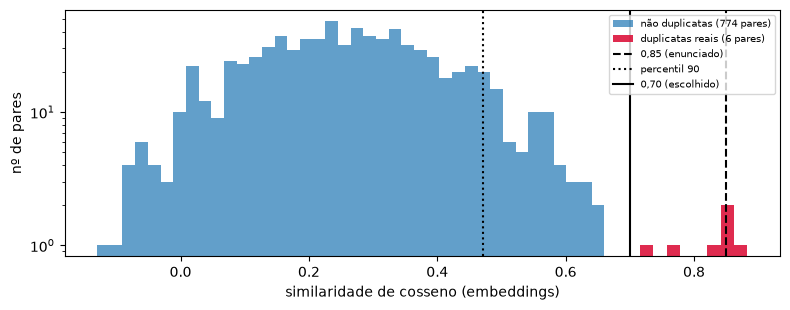

menor duplicata real = 0.715 · maior não duplicata = 0.660


,Limiar,Detectadas (de 6),Falsos positivos,Precisão,Revocação
0,"0,85 (padrão do enunciado)",1,0,1.00,0.17
1,"0,471 (percentil 90)",6,72,0.08,1.00
2,"0,70 (escolhido)",6,0,1.00,1.00


In [3]:
S = matriz_similaridade(E)
triangulo = S[np.triu_indices(len(S), 1)]
percentil_90 = float(np.percentile(triangulo, 90))
rotulo = {tuple(sorted((ids[i], ids[j]))): S[i, j] for i in range(len(ids)) for j in range(i + 1, len(ids))}
sim_dup = np.array([rotulo[p] for p in reais])
sim_nao = np.array([s for p, s in rotulo.items() if p not in reais])


def avaliar(limiar):
    previstos = {tuple(sorted((ids[i], ids[j]))) for i, j, _ in detectar_duplicatas(textos, limiar, modelo)}
    return avaliar_deteccao(previstos, reais)


e2 = pd.DataFrame([
    {"Limiar": nome, "Detectadas (de 6)": len(a["vp"]), "Falsos positivos": len(a["fp"]), "Precisão": round(a["precisao"], 2),
     "Revocação": round(a["revocacao"], 2)}
    for nome, a in [("0,85 (padrão do enunciado)", avaliar(0.85)), (f"{percentil_90:.3f} (percentil 90)".replace(".", ","), avaliar(percentil_90)),
                    ("0,70 (escolhido)", avaliar(0.70))]
])
fig, ax = plt.subplots(figsize=(8, 3.2))
ax.hist(sim_nao, bins=40, alpha=0.7, label=f"não duplicatas ({sim_nao.size} pares)")
ax.hist(sim_dup, bins=8, alpha=0.9, color="crimson", label=f"duplicatas reais ({sim_dup.size} pares)")
for valor, estilo, nome in [(0.85, "--", "0,85 (enunciado)"), (percentil_90, ":", "percentil 90"), (0.70, "-", "0,70 (escolhido)")]:
    ax.axvline(valor, color="black", linestyle=estilo, label=nome)
ax.set_yscale("log")
ax.set_xlabel("similaridade de cosseno (embeddings)")
ax.set_ylabel("nº de pares")
ax.legend(fontsize=7)
plt.tight_layout()
fig.savefig(FIGURAS / "limiar.png", dpi=150)
plt.show()
print(f"menor duplicata real = {sim_dup.min():.3f} · maior não duplicata = {sim_nao.max():.3f}")
e2

## Entrega 3 — chunking das 5 manifestações mais longas

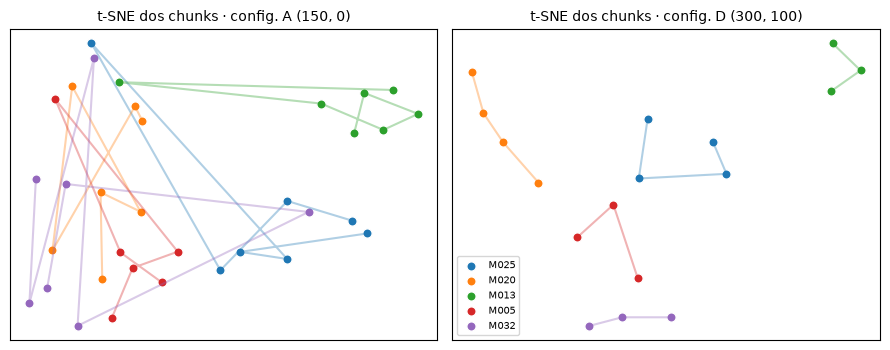

chunk_size 250: overlap 0 e 60 geram os mesmos chunks? True


,Config.,Chunks,Fragmentos,Coesão consecutiva,Recupera a origem,Vizinho da mesma manifestação
0,"A (150, 0)",34,10,0.223,0.74,0.59
1,"B (150, 50)",34,10,0.288,0.74,0.62
2,"C (300, 0)",15,0,0.480,0.87,0.73
3,"D (300, 100)",17,0,0.597,0.88,0.82


In [4]:
longas = df.assign(n=n_caracteres).nlargest(5, "n").reset_index(drop=True)
CONFIGS = {"A (150, 0)": (150, 0), "B (150, 50)": (150, 50), "C (300, 0)": (300, 0), "D (300, 100)": (300, 100)}
chunks = {}
linhas = []
for nome, (tamanho, overlap) in CONFIGS.items():
    rot, pedacos = [], []
    for m in longas.itertuples():
        cs = dividir_em_chunks(m.texto, tamanho, overlap)
        pedacos += cs
        rot += [m.id] * len(cs)
    Ec, rot = gerar_embeddings(pedacos, modelo), np.array(rot)
    chunks[nome] = (Ec, rot)
    coesao = [float(Ec[k] @ Ec[k + 1]) for k in range(len(rot) - 1) if rot[k] == rot[k + 1]]
    origem = np.array(ids)[np.argmax(Ec @ E.T, axis=1)]
    Sc = Ec @ Ec.T
    np.fill_diagonal(Sc, -np.inf)
    fragmentos = sum(not c[0].isupper() or not c.rstrip().endswith((".", "!", "?")) for c in pedacos)
    linhas.append({"Config.": nome, "Chunks": len(rot), "Fragmentos": fragmentos, "Coesão consecutiva": round(float(np.mean(coesao)), 3),
                   "Recupera a origem": round(float((origem == rot).mean()), 2),
                   "Vizinho da mesma manifestação": round(float((rot[np.argmax(Sc, axis=1)] == rot).mean()), 2)})
e3 = pd.DataFrame(linhas)

fig, eixos = plt.subplots(1, 2, figsize=(9, 3.6))
cores = dict(zip(longas["id"], plt.cm.tab10.colors))
for ax, nome in zip(eixos, ["A (150, 0)", "D (300, 100)"]):
    Ec, rot = chunks[nome]
    P = TSNE(n_components=2, perplexity=5, init="pca", random_state=42).fit_transform(Ec)
    for mid in longas["id"]:
        pts = P[rot == mid]
        ax.plot(pts[:, 0], pts[:, 1], color=cores[mid], alpha=0.35)
        ax.scatter(pts[:, 0], pts[:, 1], color=cores[mid], s=45, label=mid, edgecolor="white")
    ax.set_title(f"t-SNE dos chunks · config. {nome}", fontsize=10)
    ax.set_xticks([])
    ax.set_yticks([])
eixos[1].legend(fontsize=7)
plt.tight_layout()
fig.savefig(FIGURAS / "chunks.png", dpi=150)
plt.show()
iguais_250 = all(dividir_em_chunks(t, 250, 0) == dividir_em_chunks(t, 250, 60) for t in longas["texto"])
print("chunk_size 250: overlap 0 e 60 geram os mesmos chunks?", iguais_250)
e3

## Entrega 4 — os grupos semânticos × as categorias oficiais (aba Espaço Vetorial do app)

In [5]:
def comparar(Em):
    cat = df["categoria_oficial"].to_numpy()
    Sm = Em @ Em.T
    np.fill_diagonal(Sm, -np.inf)
    clusters = KMeans(n_clusters=5, n_init=10, random_state=0).fit_predict(Em)
    tabela = pd.crosstab(clusters, cat)
    return {"vizinho": float((cat[np.argmax(Sm, axis=1)] == cat).mean()), "ari": float(adjusted_rand_score(cat, clusters)),
            "pureza": float(tabela.max(axis=1).sum() / len(cat)), "tabela": tabela}


e4 = {nome.split("/")[-1]: comparar(gerar_embeddings(textos, carregar_modelo(nome))) for nome in MODELOS}
variancia_pca = float(PCA(n_components=2).fit(E).explained_variance_ratio_.sum())
pd.DataFrame({m: {k: round(v, 3) for k, v in r.items() if k != "tabela"} for m, r in e4.items()})

,paraphrase-multilingual-MiniLM-L12-v2,all-MiniLM-L6-v2
vizinho,0.700,0.575
ari,0.489,0.313
pureza,0.750,0.625


## Montagem do relatório

In [6]:
def tabela_md(t: pd.DataFrame) -> str:
    fmt = lambda v: f"{v:.3f}".rstrip("0").rstrip(".").replace(".", ",") if isinstance(v, float) else str(v)
    linhas = ["| " + " | ".join(t.columns) + " |", "|" + "---|" * len(t.columns)]
    linhas += ["| " + " | ".join(fmt(v) for v in r) + " |" for r in t.itertuples(index=False)]
    return "\n".join(linhas)


num = lambda v, casas=3: f"{v:.{casas}f}".replace(".", ",")
pct = lambda v: f"{v:.0%}"
cats = ", ".join(f"{c} ({n})" for c, n in dados["categorias"].items())
mult, ingl = e4["paraphrase-multilingual-MiniLM-L12-v2"], e4["all-MiniLM-L6-v2"]
D, A = e3.set_index("Config.").loc["D (300, 100)"], e3.set_index("Config.").loc["A (150, 0)"]
C = e3.set_index("Config.").loc["C (300, 0)"]

RELATORIO = f'''# Ouvidoria Inteligente — Relatório Final

Triagem semântica de manifestações cidadãs · Tendências em Ciência da Computação · Prof. Me. Ricardo Roberto de Lima · **Autor:** Victor (entrega individual) · {DATA_RELATORIO:%d/%m/%Y}.

## 1. Visão geral

A ouvidoria faz a triagem por palavras-chave e por isso não detecta duplicatas, não agrupa temas relacionados e perde contexto em relatos longos. O protótipo troca as palavras-chave por representações vetoriais. Todas as entregas usam o mesmo módulo (`ouvidoria.py`) e os mesmos dados.

| Entrega | Decisão principal | Resultado |
|---|---|---|
| 1. Representações | embeddings multilíngues contra BoW e TF-IDF | só os embeddings separam duplicatas de temas diferentes |
| 2. Duplicatas | limiar 0,70 em vez de 0,85 | 6 de 6 duplicatas, nenhum falso positivo |
| 3. Chunking | chunks de 300 caracteres com 100 de overlap | nenhum fragmento; {pct(D["Recupera a origem"])} dos chunks apontam para a própria denúncia |
| 4. App Streamlit | 4 abas, cache do modelo, modelo e top-k na barra lateral | busca por significado, matriz, espaço vetorial e chunking |

Arquivos: `análise_comparativa.ipynb`, `deteccao_duplicatas.ipynb`, `chunking_manifestacoes.ipynb` e `app_ouvidoria.py`.

## 2. Dados

O enunciado diz que o `manifestacoes.json` é fornecido, mas nesta turma cada aluno monta o seu. **Decisões:** {dados["n"]} manifestações no esquema da seção 2 (id, data, categoria oficial e texto de {dados["min"]} a {dados["max"]} caracteres), nas categorias {cats}. Há {dados["duplicatas"]} pares de duplicatas semânticas (15%), escritos com vocabulário diferente, e {dados["longas"]} relatos com mais de 500 caracteres. Os trechos citados nos pares da Entrega 1 aparecem dentro de relatos completos, porque sozinhos ficariam abaixo do mínimo de 50 caracteres. O esquema não tem campo que marque duplicatas, então o gabarito ficou num arquivo à parte (`duplicatas_reais.json`).

## 3. Entrega 1 — representações

**Decisões:** BoW (`CountVectorizer`) e TF-IDF (`TfidfVectorizer`) com uma lista de stopwords em português, porque o scikit-learn só traz a lista em inglês. Para os embeddings, `paraphrase-multilingual-MiniLM-L12-v2`, o primeiro modelo sugerido; o segundo, `BAAI/bge-small-pt-v1.5`, não existe no Hugging Face.

{tabela_md(e1)}

Nas representações esparsas, os pares duplicados só têm em comum nomes próprios (“Sete de Setembro”, “São José”) e ficam quase tão distantes quanto o par sem relação. Os embeddings dão {num(e1.at[0, "Embeddings"])} e {num(e1.at[1, "Embeddings"])} às duplicatas e {num(e1.at[2, "Embeddings"])} ao par de temas diferentes. **Limitações:** BoW e TF-IDF não veem sinônimos nem paráfrases; os embeddings não explicam a nota e dependem do modelo (e do idioma em que ele foi treinado).

## 4. Entrega 2 — duplicatas

**Decisões:** `detectar_duplicatas(textos, limiar=0.85)` mantém o padrão pedido, compara com “acima do limiar” (`>`) e devolve todos os pares i < j. O limiar foi escolhido por uma varredura de 0,50 a 0,90 contra o gabarito, incluindo o percentil 90 sugerido na seção 7.

{tabela_md(e2)}

![Figura 1 — distribuição das similaridades entre os 780 pares e os limiares comparados.](figuras/limiar.png)

A menor duplicata real tem {num(sim_dup.min())} e a maior não duplicata tem {num(sim_nao.max())}: 0,70 fica entre as duas. O 0,85 perde paráfrases com vocabulário diferente (“vender drogas” × “tráfico de drogas”). O percentil 90 marca por construção 10% dos pares e confunde “mesmo tema” com “mesmo problema”. Como a folga é estreita e o limiar foi calibrado em 40 manifestações, a recomendação é usar a detecção para **sugerir** duplicatas a um atendente, sem fundir manifestações automaticamente.

## 5. Entrega 3 — chunking

**Decisões:** `RecursiveCharacterTextSplitter` com separadores parágrafo → linha → frase → palavra, e quatro configurações: dois tamanhos, cada um com e sem overlap, para isolar o efeito do overlap. Além de exemplos, três medidas: fragmentos, coesão entre chunks consecutivos e se o chunk sozinho ainda aponta para a própria manifestação entre as 40.

{tabela_md(e3)}

![Figura 2 — chunks das 5 manifestações longas no t-SNE: com uma frase por chunk (A) eles se misturam; com a configuração D, cada denúncia forma uma trilha.](figuras/chunks.png)

O overlap aumentou a coesão nos dois tamanhos, mas o splitter repete **pedaços inteiros** (frases, ou palavras quando a frase foi quebrada), e não uma janela de caracteres. Com `chunk_size` 250, overlap 0 e 60 geram os mesmos chunks. A configuração D preserva melhor o sentido: cada chunk tem de 2 a 3 frases completas. Com chunks de uma frase, surgem fragmentos como “estavam no trabalho.”, e os chunks passam a se agrupar pelo assunto da frase (burocracia, danos à saúde), não pela denúncia.

## 6. Entrega 4 — app Streamlit

**Arquitetura:** `app_ouvidoria.py` separa a lógica (ranking, projeção 2D, comparação com as categorias, chunking) da interface (`main()`) e reaproveita o `ouvidoria.py`. O modelo fica em `st.cache_resource`, e os embeddings, as projeções e as métricas em `st.cache_data`. A barra lateral escolhe o modelo (multilíngue ou `all-MiniLM-L6-v2`, para comparação) e o top-k, com padrão 5. As abas são Busca Semântica (score em verde acima de 0,7, amarelo acima de 0,5 e vermelho nos demais), Base Completa (tabela e botão da matriz), Espaço Vetorial (PCA ou t-SNE por categoria) e Chunking (estratégia, `chunk_size` e `chunk_overlap`, com padrão 300/100 vindo da Entrega 3).

**Os clusters coincidem com as categorias? Em parte.** Com o modelo multilíngue, {pct(mult["vizinho"])} das manifestações têm como vizinho mais próximo uma da mesma categoria, e o K-Means com 5 grupos tem ARI {num(mult["ari"], 2)} e pureza {pct(mult["pureza"])}. Saúde forma um grupo puro e completo. Infraestrutura e meio ambiente se misturam, porque o embedding agrupa pelo cenário (rua, trânsito, água e lixo), enquanto a categoria é administrativa. Com o `all-MiniLM-L6-v2`, treinado só em inglês, os números caem para {pct(ingl["vizinho"])} e ARI {num(ingl["ari"], 2)}. Na aba Espaço Vetorial, as métricas são calculadas no espaço original: o PCA com 2 componentes guarda só {pct(variancia_pca)} da variância.

## 7. Dificuldades

- **Montar os dados.** As duplicatas não podiam ser cópias literais, porque aí até o BoW as acharia, e os relatos longos tinham de caber em 800 caracteres com várias frases.
- **O limiar do enunciado.** Com 0,85 o detector achava 1 duplicata de 6. Foi preciso um gabarito e uma varredura para escolher outro limiar, e a folga entre as classes é pequena.
- **O overlap que “não fazia nada”.** As configurações (250, 0) e (250, 60) davam chunks idênticos. Entender o motivo exigiu ler como o splitter monta o overlap com pedaços inteiros.
- **Projeções 2D enganam.** O PCA sobrepõe grupos que estão separados em 384 dimensões. As conclusões passaram a se apoiar em medidas no espaço original, e a figura virou só ilustração.
- **Peso dos modelos.** O modelo multilíngue tem ≈ 470 MB e a primeira carga é lenta. O cache do Streamlit resolveu o uso normal, e um modo sem rede (`OUVIDORIA_EMBEDDER=falso`, com um embedder determinístico local) permitiu desenvolver a interface sem baixar o modelo.

## 8. Aprendizados

- **Esparso × denso.** Contar palavras funciona quando os textos dividem vocabulário. Para paráfrases, só as representações densas aproximam os textos certos.
- **Limiar é calibração, não constante.** Ele depende do modelo e dos dados, precisa de gabarito e deve alimentar uma decisão humana.
- **No chunking, o tamanho importa mais que o overlap.** Um chunk precisa carregar o sujeito da denúncia. O overlap ajuda na continuidade, mas não salva um chunk pequeno demais e custa texto repetido no índice.
- **Similaridade semântica ≠ categoria administrativa.** Os embeddings servem para sugerir a categoria e achar temas relacionados, mas não substituem a classificação oficial.
- **Medir antes de afirmar.** Cada conclusão das entregas veio acompanhada do número que a sustenta, e este relatório recalcula esses números a partir do código.
'''
Path("RELATORIO.md").write_text(RELATORIO, encoding="utf-8")
paginas = gerar_pdf("RELATORIO.md", "RELATORIO.pdf", data=DATA_RELATORIO)
print(f"RELATORIO.pdf gerado com {paginas} página(s)")

RELATORIO.pdf gerado com 3 página(s)
